In [1]:
import numpy as np # linear algebra
#import random
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2
import random
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#import shutil
from glob import glob
# Helper libraries
import matplotlib.pyplot as plt
#import math
%matplotlib inline
#print(tf.__version__)

C:\Users\dell\.anaconda\anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data_root="dataset"
path_Diabetic_retina_cases = os.path.join("dataset\Diabetic retina")
path_normal_cases=os.path.join(r"C:\Users\dell\Downloads\diabetic retinopathy with flask\dataset\normal")


### Datasets Overview

In [3]:
# jpg and png files
Diabetic_retina_images_ls = glob(os.path.join(path_Diabetic_retina_cases, "*.jpg"))
normal_images_ls = glob(os.path.join(path_normal_cases,"*.jpg"))
normal_images_ls.extend(glob(os.path.join(path_normal_cases,"*.jpg")))
len(normal_images_ls)


500

In [4]:
Diabetic_retina = {'class': 'Diabetic retina',
                   'path': path_Diabetic_retina_cases,
                   'images': Diabetic_retina_images_ls}

normal = {'class': 'normal',
             'path': path_normal_cases,
             'images': normal_images_ls}


In [5]:
total_Diabetic_retina = len(Diabetic_retina_images_ls)
total_normal = len(normal_images_ls)

print("Total Diabetic retina images: {}".format(total_Diabetic_retina))
print("Total normal images: {}".format(total_normal))


Total Diabetic retina images: 506
Total normal images: 500


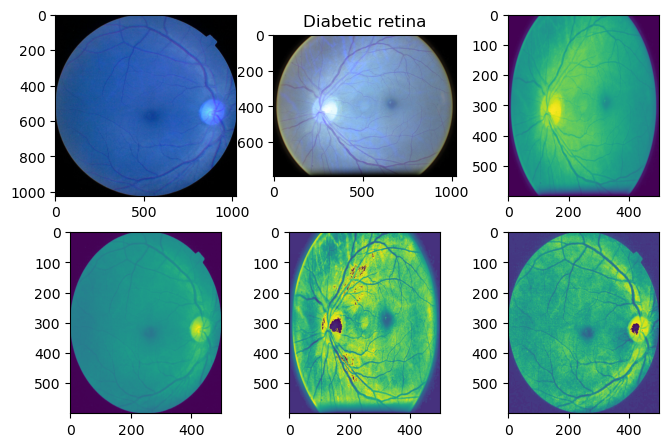

In [6]:
import cv2
import os
import matplotlib.pyplot as plt
image_Diabetic_retina = cv2.imread(os.path.join(Diabetic_retina_images_ls[1]))
image_normal = cv2.imread(os.path.join(normal_images_ls[0]))
image1 = cv2.resize(image_Diabetic_retina, (500, 600))
image2 = cv2.resize(image_normal, (500, 600))
# The initial processing of the image
# image = cv2.medianBlur(image, 3)
image_gr1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
image_gr2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit = 5)
final_img1 = clahe.apply(image_gr1) + 30
final_img2 = clahe.apply(image_gr2) + 30
# Ordinary thresholding the same image
_, ordinary_img1 = cv2.threshold(image_gr1, 155, 255, cv2.THRESH_BINARY)
_, ordinary_img2= cv2.threshold(image_gr2, 155, 255, cv2.THRESH_BINARY)
# Showing all the three images
f = plt.figure(figsize=(8, 8))
f.add_subplot(3, 3, 1)
plt.imshow(image_normal)
f.add_subplot(3, 3, 2)
plt.imshow(image_Diabetic_retina)

plt.title("Diabetic retina")
f.add_subplot(3, 3, 3)
plt.imshow(image_gr1)
f.add_subplot(3, 3, 4)
plt.imshow(image_gr2)
f.add_subplot(3, 3, 5)
plt.imshow(final_img1)
f.add_subplot(3, 3, 6)
plt.imshow(final_img2)


In [7]:
print("Image Diabetic retina Shape {}".format(image_Diabetic_retina.shape))
print("Image normal Shape {}".format(image_normal.shape))


Image Diabetic retina Shape (789, 1024, 3)
Image normal Shape (1024, 1024, 3)


In [8]:
# Create Train-Test Directory
subdirs  = ['train/', 'test/']
for subdir in subdirs:
    labeldirs = ['Diabetic retina', 'normal']
    for labldir in labeldirs:
        newdir = subdir + labldir
        os.makedirs(newdir, exist_ok=True)
        print(newdir)

train/Diabetic retina
train/normal
test/Diabetic retina
test/normal


In [9]:
total_train_Diabetic_retina = len(os.listdir("train\Diabetic retina"))
total_train_normal = len(os.listdir(r"C:\Users\dell\Downloads\diabetic retinopathy with flask\train\normal"))
total_test_Diabetic_retina = len(os.listdir("test\Diabetic retina"))
total_test_normal =len(os.listdir(r"train\normal"))


print("Train sets images Diabetic retina: {}".format(total_train_Diabetic_retina))
print("Train sets images normal: {}".format(total_train_normal))
print("Test sets images Diabetic retina: {}".format(total_test_Diabetic_retina))
print("Test sets images normal: {}".format(total_test_normal))

Train sets images Diabetic retina: 506
Train sets images normal: 250
Test sets images Diabetic retina: 506
Test sets images normal: 250


#CNN MODEL

In [10]:
batch_size =55
epochs = 5
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [11]:
train_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our training data
test_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our validation data

In [12]:
train_dir = os.path.join(r"C:\Users\dell\Downloads\diabetic retinopathy with flask\train")
test_dir = os.path.join(r"C:\Users\dell\Downloads\diabetic retinopathy with flask\test")


total_train = total_train_Diabetic_retina + total_train_normal
total_test = total_test_Diabetic_retina + total_test_normal

In [13]:
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                           directory=train_dir,
                                                           shuffle=True,
                                                           target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                           class_mode='binary')

Found 756 images belonging to 2 classes.


In [14]:
test_data_gen = test_image_generator.flow_from_directory(batch_size=batch_size,
                                                              directory=test_dir,
                                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              class_mode='binary')

Found 756 images belonging to 2 classes.


In [15]:
model = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH ,3)),
    MaxPooling2D(2, 2),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1)

])

C:\Users\dell\.anaconda\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20736)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      10,617,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,674,177 (40.72 MB)

 Trainable params: 10,674,177 (40.72 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=epochs,
    validation_data=test_data_gen,
    validation_steps=total_test // batch_size
)


Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.7290 - loss: 0.6151 - val_accuracy: 0.8364 - val_loss: 0.4121
Epoch 2/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7818 - loss: 0.5504

C:\Users\dell\.anaconda\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7818 - loss: 0.5504 - val_accuracy: 0.8545 - val_loss: 0.3803
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.8302 - loss: 0.3491 - val_accuracy: 0.9021 - val_loss: 0.2528
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9273 - loss: 0.2134 - val_accuracy: 0.9049 - val_loss: 0.2388
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.9116 - loss: 0.2166 - val_accuracy: 0.9231 - val_loss: 0.1704


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
normal


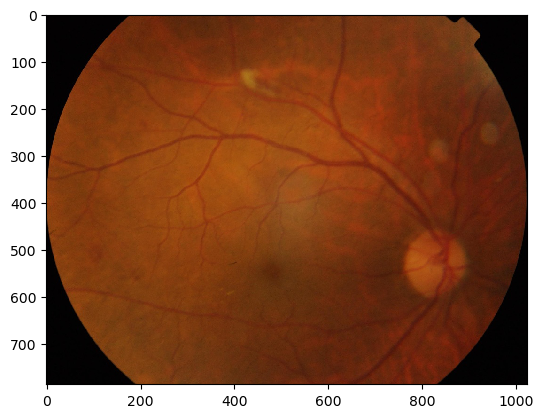

In [19]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

load_input=mpimg.imread(r"C:\Users\dell\Downloads\diabetic retinopathy with flask\test\normal\5b72ff04333d.jpg")
imgplot = plt.imshow(load_input, interpolation='none')

load_input = image.load_img(r"C:\Users\dell\Downloads\diabetic retinopathy with flask\test\normal\5b72ff04333d.jpg", target_size = (150, 150))


test_image = image.img_to_array(load_input)
test_image = np.expand_dims(test_image, axis = 0)
result = model.predict(test_image)
#print(result)
if result>=1:
    print( 'normal')
else:
    print( 'diabetic retina')
    




In [20]:
model.save_weights("model_vgg.weights.h5")
print("Saved model to disk")

Saved model to disk


In [21]:
model_json=model.to_json()
with open("model_vgg.json", "w") as json_file:
    json_file.write(model_json)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import numpy as np
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Dense
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import numpy as np
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Dense
from keras.models import model_from_json
import tensorflow as tf
from flask import Flask, render_template, request, send_from_directory

app = Flask(__name__)


UPLOAD_FOLDER = "uploads"
STATIC_FOLDER = "static"
json_file = open('model_vgg.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
cnn_model = model_from_json(loaded_model_json)
# load weights into new model
cnn_model.load_weights("model_vgg.h5")
# Load model

IMAGE_SIZE = 150

# Preprocess an image
def preprocess_image(image):
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image /= 255.0  # normalize to [0,1] range

    return image


# Read the image from path and preprocess
def load_and_preprocess_image(path):
    image = tf.io.read_file(path)

    return preprocess_image(image)


# Predict & classify image
def classify(model, image_path):

    preprocessed_imgage = load_and_preprocess_image(image_path)
    preprocessed_imgage = tf.reshape(
        preprocessed_imgage, (1, IMAGE_SIZE, IMAGE_SIZE, 3)
    )

    prob = cnn_model.predict(preprocessed_imgage)
    label = "normal" if prob[0][0] >= 0.5 else "Diabetic retina"
    classified_prob = prob[0][0] if prob[0][0] >= 0.5 else 1 - prob[0][0]

    return label, classified_prob


# home page
@app.route("/")
def home():
    return render_template("home.html")


@app.route("/classify", methods=["POST", "GET"])
def upload_file():

    if request.method == "GET":
        return render_template("home.html")

    else:
        file = request.files["image"]
        upload_image_path = os.path.join(UPLOAD_FOLDER, file.filename)
        print(upload_image_path)
        file.save(upload_image_path)

        label, prob = classify(cnn_model, upload_image_path)

        prob = round((prob * 100), 2)

    return render_template(
        "classify.html", image_file_name=file.filename, label=label, prob=prob
    )


@app.route("/classify/<filename>")
def send_file(filename):
    return send_from_directory(UPLOAD_FOLDER, filename)


if __name__ == "__main__":

    app.run()



 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [16/Feb/2026 01:29:50] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:29:50] "GET /static/script.js HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:29:50] "GET /static/images/retina.jpeg HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:29:50] "GET /static/images/images.jpeg HTTP/1.1" 304 -


uploads\3c28fd846b43.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


127.0.0.1 - - [16/Feb/2026 01:30:06] "POST /classify HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:30:06] "GET /classify/3c28fd846b43.jpg HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:30:06] "GET /static/script.js HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:30:06] "GET /static/images/images.jpeg HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:30:46] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:30:46] "GET /static/images/retina.jpeg HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:30:46] "GET /static/script.js HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:30:46] "GET /static/images/images.jpeg HTTP/1.1" 304 -


uploads\30505_left.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


127.0.0.1 - - [16/Feb/2026 01:31:03] "POST /classify HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:31:03] "GET /classify/30505_left.jpg HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:31:03] "GET /static/script.js HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:31:03] "GET /static/images/images.jpeg HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:31:21] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:31:21] "GET /static/images/retina.jpeg HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:31:21] "GET /static/script.js HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:31:21] "GET /static/images/images.jpeg HTTP/1.1" 304 -


uploads\3c28fd846b43.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


127.0.0.1 - - [16/Feb/2026 01:31:54] "POST /classify HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:31:54] "GET /classify/3c28fd846b43.jpg HTTP/1.1" 200 -
127.0.0.1 - - [16/Feb/2026 01:31:54] "GET /static/script.js HTTP/1.1" 304 -
127.0.0.1 - - [16/Feb/2026 01:31:54] "GET /static/images/images.jpeg HTTP/1.1" 304 -
